In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.utils.class_weight import compute_class_weight


from imblearn.over_sampling import KMeansSMOTE, SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours, RepeatedEditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek


import plotly as py
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot, plot
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart_no_outliers.csv to heart_no_outliers.csv


In [3]:
data = pd.read_csv('heart_no_outliers.csv')
df_original = pd.DataFrame(data)

In [4]:
df_original.duplicated().sum()

190

In [5]:
df_original.drop_duplicates(inplace=True)
df_original.duplicated().sum()

0

In [6]:
df = df_original.copy()

In [7]:
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.metrics import fbeta_score
import optuna

def objective(trial):
    class_1_weight = trial.suggest_float('class_1_weight', 1, 20)
    weights = {0: 1, 1: class_1_weight}
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight=weights)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    return f2



In [53]:
best_weight = study.best_params['class_1_weight']
final_weights = {0: 1, 1: 5}

logreg_final = LogisticRegression(max_iter=1000, random_state=42, class_weight=final_weights)
logreg_final.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(class_weight={0: 1, 1: 5}, max_iter=1000, random_state=42)

In [54]:
y_pred_proba = logreg_final.predict_proba(X_test)[:, 1]
threshold = 0.28
y_pred_custom = (y_pred_proba > threshold).astype(int)

# Evaluation
final_f2 = fbeta_score(y_test, y_pred_custom, beta=2)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1 Score:", f1_score(y_test, y_pred_custom))
print("F2 Score:", final_f2)
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.8720309099584531
Precision: 0.26097069313071797
Recall: 0.6968944099378882
F1 Score: 0.37973826714801445
F2 Score: 0.5223787944627227
AUC: 0.8818783150336721


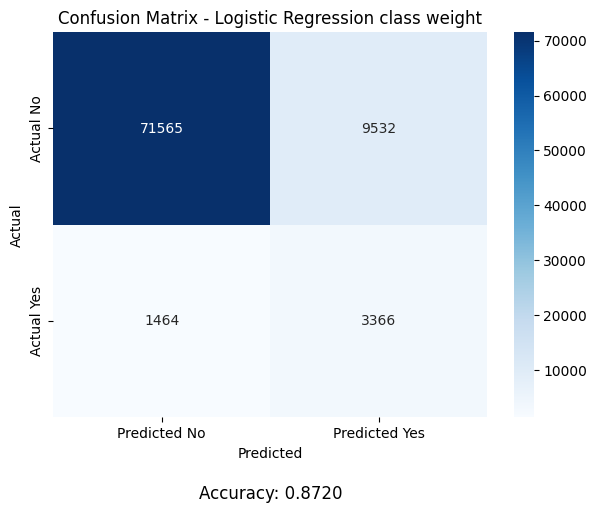

In [55]:
conf_matrix_smote = confusion_matrix(y_test, y_pred_custom)
logreg_acc_score_smote = accuracy_score(y_test, y_pred_custom)


plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])

plt.title('Confusion Matrix - Logistic Regression class weight')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.text(0.5, -0.2, f'Accuracy: {logreg_acc_score_smote:.4f}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)

plt.show()